# Загрузка библиотек

In [1]:
%load_ext autoreload
%autoreload 2

In [66]:
import pandas as pd
import sys
import os
import numpy
import matplotlib.pyplot as plt
import shap
import featurewiz
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTENC
from sklearn.utils import class_weight

In [3]:
sys.path.append('../utils_functionality/')
from data_analysis.split_analisys import *
from data_analysis.reports import *
from models.class_models import *

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
RANDOM_STATE = 42

# Загрузка данных и разделение на train, test

In [6]:
df = pd.read_excel('../data/df_merged_edited.xlsx', index_col=[0])
train, test = train_test_split(df, test_size=0.33, random_state=RANDOM_STATE)

# Моделирование

## Baseline 1. Featurewiz + XGBoost

### Splashing

In [7]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 24)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [8]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.850746,0.876923,0.863636,65.000000
1,0.857143,0.827586,0.842105,58.000000
accuracy,0.853659,0.853659,0.853659,0.853659
macro avg,0.853945,0.852255,0.852871,123.000000
weighted avg,0.853763,0.853659,0.853483,123.000000


#### Cross-Validation

In [9]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	80.97% (std: 2.51%)
F1 Test:	79.55% (std: 5.16%)


#### SHAP interpretation

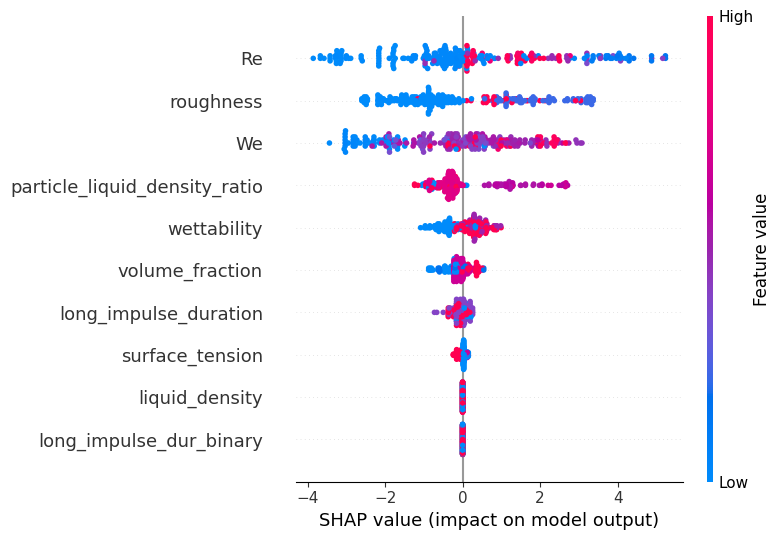

In [10]:
get_shap_interpretation(model, X_train)

#### Net impact

In [11]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 24)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [12]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.857143,0.951220,0.901734,82.000000
1,0.875000,0.682927,0.767123,41.000000
accuracy,0.861789,0.861789,0.861789,0.861789
macro avg,0.866071,0.817073,0.834429,123.000000
weighted avg,0.863095,0.861789,0.856864,123.000000


In [13]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	70.84% (std: 7.44%)
F1 Test:	77.88% (std: 11.39%)


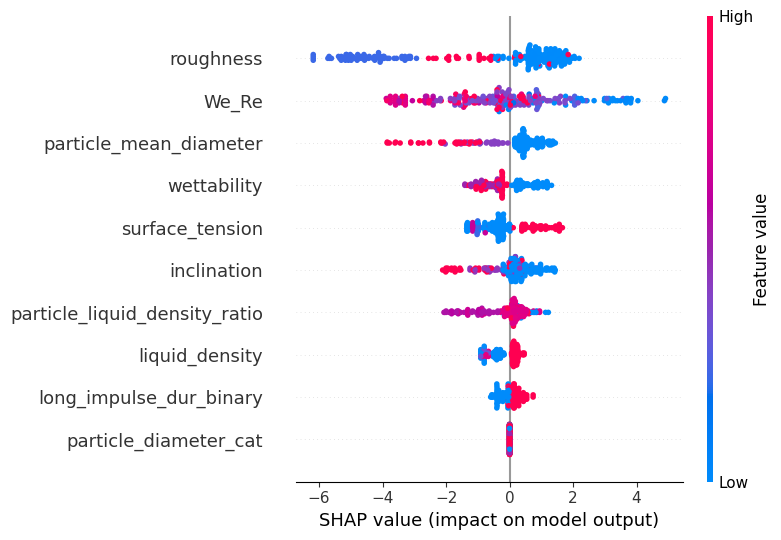

In [14]:
get_shap_interpretation(model, X_train)

## Baseline 2. Featurewiz + XGBoost

### Splashing

In [15]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 24)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [16]:
smote_nc = SMOTENC(categorical_features=[7], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [17]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.852941,0.892308,0.872180,65.000000
1,0.872727,0.827586,0.849558,58.000000
accuracy,0.861789,0.861789,0.861789,0.861789
macro avg,0.862834,0.859947,0.860869,123.000000
weighted avg,0.862271,0.861789,0.861513,123.000000


#### Cross-Validation

In [18]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	84.66% (std: 4.54%)
F1 Test:	79.55% (std: 5.16%)


#### SHAP interpretation

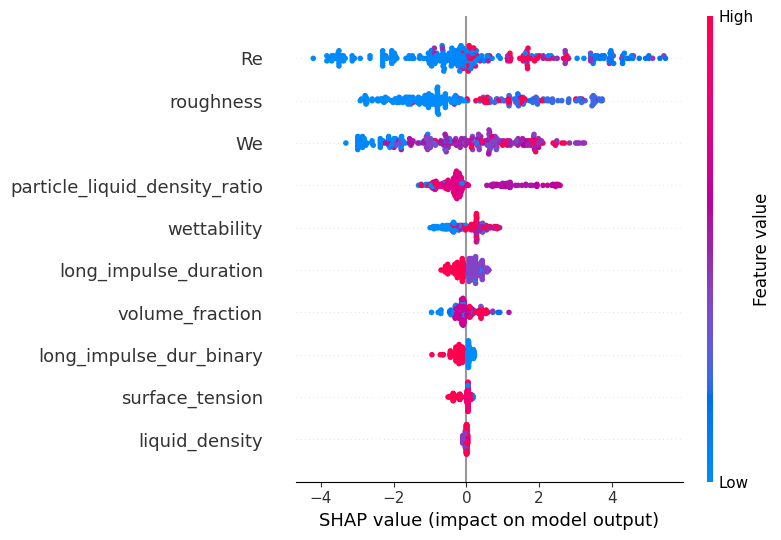

In [19]:
get_shap_interpretation(model, X_train)

### net_impact

In [20]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 24)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [21]:
smote_nc = SMOTENC(categorical_features=[7], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [22]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.866667,0.951220,0.906977,82.000000
1,0.878788,0.707317,0.783784,41.000000
accuracy,0.869919,0.869919,0.869919,0.869919
macro avg,0.872727,0.829268,0.845380,123.000000
weighted avg,0.870707,0.869919,0.865912,123.000000


#### Cross-Validation

In [23]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	86.62% (std: 4.67%)
F1 Test:	77.88% (std: 11.39%)


#### SHAP interpretation

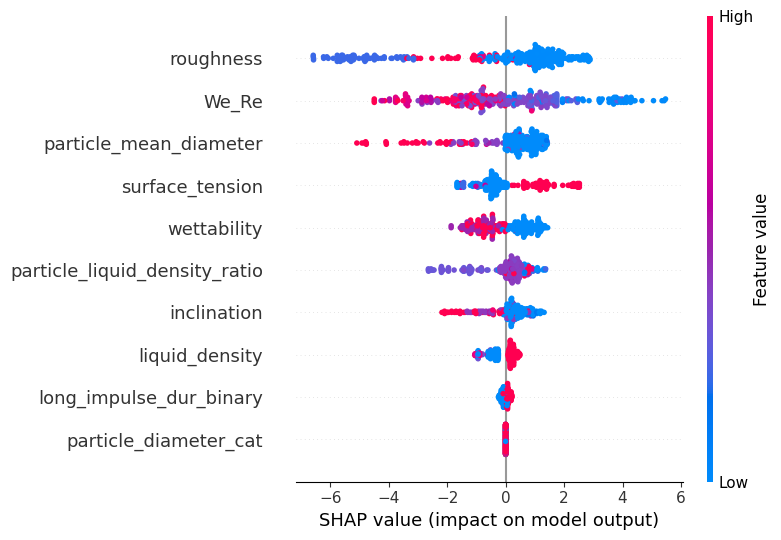

In [24]:
get_shap_interpretation(model, X_train)

# Модель на признаках из сообщения от 11 апреля в 10:09 в tg


Со Splashing и net_impact посложнее.

- По Re и We: возможны два датасета, в одном Re и We (два признака), в другом We_Re (один признак, либо ещё оставить We исходя из отсутствия мультиколлинеарности с We_Re)
- Второй важный признак тоже wettability_lyophobic
- Далее:
  - volume_fraction_binary, 
  - particle_liquid_density_ratio, 
  - particle_droplet_diameter_ratio (или particle_diameter_cat_large & _small),  
  - и возможно roughness_binary,

In [47]:
features = ['We', 'We_Re', 
'wettability_lyophobic', 'volume_fraction_binary', 
'particle_liquid_density_ratio', 'particle_droplet_diameter_ratio', 
'roughness_binary']

## Spalashing

In [57]:
cs = CreateSamples(df, train, test, features=features, target='splashing', dummies=True)
X_train, X_test, y_train, y_test = cs.get_samples()

In [58]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.833333,0.846154,0.839695,65.000000
1,0.824561,0.810345,0.817391,58.000000
accuracy,0.829268,0.829268,0.829268,0.829268
macro avg,0.828947,0.828249,0.828543,123.000000
weighted avg,0.829197,0.829268,0.829178,123.000000


In [59]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	78.86% (std: 4.02%)
F1 Test:	70.23% (std: 5.12%)


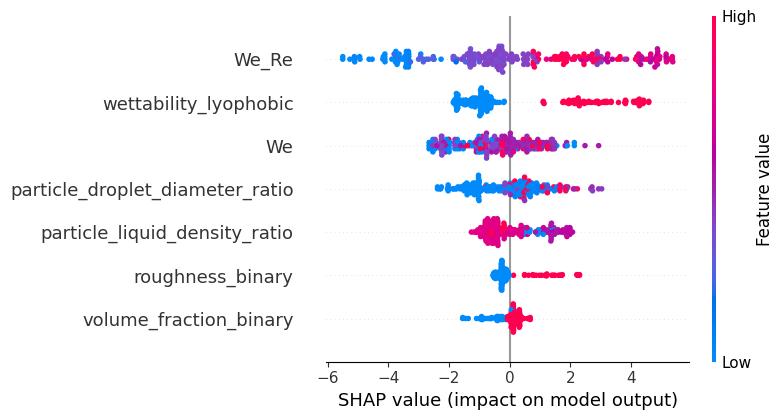

In [60]:
get_shap_interpretation(model, X_train)

## Net-impact

In [62]:
cs = CreateSamples(df, train, test, features=features, target='net_impact', dummies=True)
X_train, X_test, y_train, y_test = cs.get_samples()

In [63]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

,precision,recall,f1-score,support
0,0.879518,0.890244,0.884848,82.000000
1,0.775000,0.756098,0.765432,41.000000
accuracy,0.845528,0.845528,0.845528,0.845528
macro avg,0.827259,0.823171,0.825140,123.000000
weighted avg,0.844679,0.845528,0.845043,123.000000


In [64]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	63.79% (std: 3.56%)
F1 Test:	62.84% (std: 14.14%)


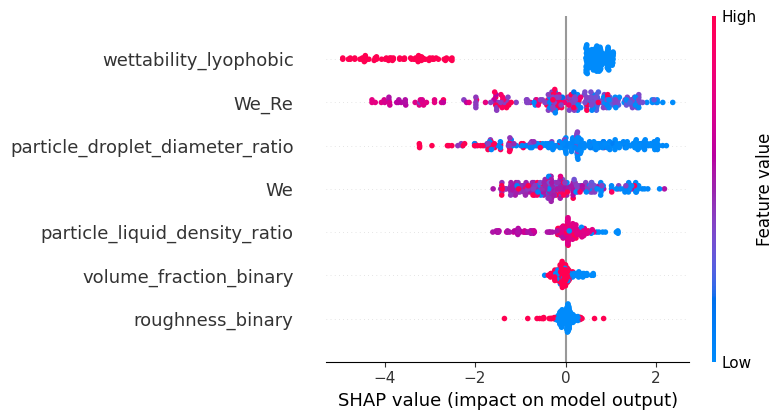

In [65]:
get_shap_interpretation(model, X_train)

# CatBoost на тех же признаках

## Spalashing

In [67]:
cs = CreateSamples(df, train, test, features=features, target='splashing', dummies=True)
X_train, X_test, y_train, y_test = cs.get_samples()

In [68]:
model = CatBoostClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

Learning rate set to 0.00569
0:	learn: 0.6898768	total: 124ms	remaining: 2m 4s
1:	learn: 0.6855828	total: 128ms	remaining: 1m 3s
2:	learn: 0.6816137	total: 130ms	remaining: 43.4s
3:	learn: 0.6776166	total: 132ms	remaining: 32.9s
4:	learn: 0.6734942	total: 134ms	remaining: 26.7s
5:	learn: 0.6696310	total: 136ms	remaining: 22.5s
6:	learn: 0.6663505	total: 138ms	remaining: 19.6s
7:	learn: 0.6621215	total: 140ms	remaining: 17.3s
8:	learn: 0.6588095	total: 142ms	remaining: 15.6s
9:	learn: 0.6549500	total: 144ms	remaining: 14.2s
10:	learn: 0.6516745	total: 147ms	remaining: 13.2s
11:	learn: 0.6492162	total: 148ms	remaining: 12.2s
12:	learn: 0.6459430	total: 150ms	remaining: 11.4s
13:	learn: 0.6431502	total: 152ms	remaining: 10.7s
14:	learn: 0.6412476	total: 153ms	remaining: 10s
15:	learn: 0.6389886	total: 154ms	remaining: 9.47s
16:	learn: 0.6355667	total: 156ms	remaining: 9.01s
17:	learn: 0.6332758	total: 158ms	remaining: 8.59s
18:	learn: 0.6305764	total: 159ms	remaining: 8.22s
19:	learn: 0.6

,precision,recall,f1-score,support
0,0.859375,0.846154,0.852713,65.000000
1,0.830508,0.844828,0.837607,58.000000
accuracy,0.845528,0.845528,0.845528,0.845528
macro avg,0.844942,0.845491,0.845160,123.000000
weighted avg,0.845763,0.845528,0.845590,123.000000


In [69]:
get_cv_results(model, X_train, y_train, X_test, y_test)

Learning rate set to 0.005171
0:	learn: 0.6902202	total: 2.74ms	remaining: 2.74s
1:	learn: 0.6866770	total: 4.8ms	remaining: 2.39s
2:	learn: 0.6835749	total: 6.57ms	remaining: 2.18s
3:	learn: 0.6814390	total: 10ms	remaining: 2.49s
4:	learn: 0.6782104	total: 12ms	remaining: 2.39s
5:	learn: 0.6744568	total: 13.4ms	remaining: 2.22s
6:	learn: 0.6719284	total: 15.4ms	remaining: 2.18s
7:	learn: 0.6696081	total: 16.9ms	remaining: 2.1s
8:	learn: 0.6661520	total: 18.5ms	remaining: 2.04s
9:	learn: 0.6642656	total: 19.5ms	remaining: 1.93s
10:	learn: 0.6608144	total: 21.4ms	remaining: 1.92s
11:	learn: 0.6573655	total: 23.3ms	remaining: 1.92s
12:	learn: 0.6540976	total: 25.7ms	remaining: 1.95s
13:	learn: 0.6512451	total: 29.7ms	remaining: 2.09s
14:	learn: 0.6477191	total: 31.3ms	remaining: 2.06s
15:	learn: 0.6447801	total: 32.9ms	remaining: 2.02s
16:	learn: 0.6419216	total: 34.8ms	remaining: 2.01s
17:	learn: 0.6389392	total: 36.6ms	remaining: 2s
18:	learn: 0.6355153	total: 38.1ms	remaining: 1.97s
1

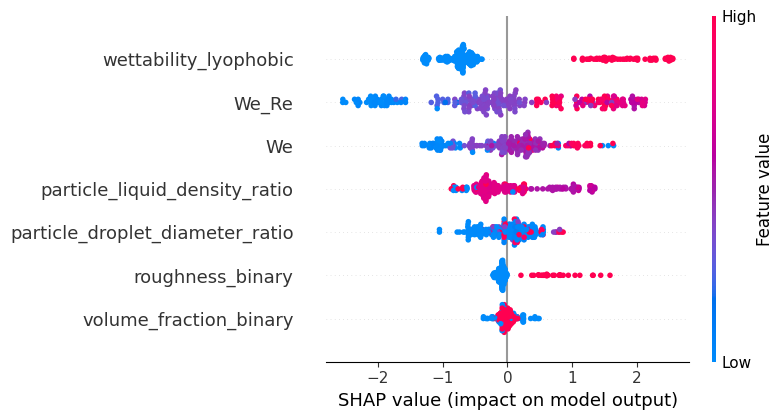

In [70]:
get_shap_interpretation(model, X_train)

## Net-impact

In [71]:
cs = CreateSamples(df, train, test, features=features, target='net_impact', dummies=True)
X_train, X_test, y_train, y_test = cs.get_samples()

In [72]:
model = CatBoostClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)

Learning rate set to 0.00569
0:	learn: 0.6889140	total: 1.86ms	remaining: 1.86s
1:	learn: 0.6840860	total: 3.68ms	remaining: 1.84s
2:	learn: 0.6800508	total: 5.49ms	remaining: 1.82s
3:	learn: 0.6762270	total: 6.75ms	remaining: 1.68s
4:	learn: 0.6724011	total: 8.14ms	remaining: 1.62s
5:	learn: 0.6684894	total: 9.65ms	remaining: 1.6s
6:	learn: 0.6649087	total: 10.9ms	remaining: 1.55s
7:	learn: 0.6614244	total: 12.3ms	remaining: 1.53s
8:	learn: 0.6577422	total: 13.7ms	remaining: 1.5s
9:	learn: 0.6540012	total: 14.4ms	remaining: 1.42s
10:	learn: 0.6504184	total: 15.9ms	remaining: 1.43s
11:	learn: 0.6472204	total: 17.3ms	remaining: 1.42s
12:	learn: 0.6435937	total: 18.7ms	remaining: 1.42s
13:	learn: 0.6401517	total: 20ms	remaining: 1.41s
14:	learn: 0.6369081	total: 21.3ms	remaining: 1.4s
15:	learn: 0.6334692	total: 22.8ms	remaining: 1.4s
16:	learn: 0.6298618	total: 24.1ms	remaining: 1.39s
17:	learn: 0.6267642	total: 25.6ms	remaining: 1.4s
18:	learn: 0.6236660	total: 27.1ms	remaining: 1.4s
1

,precision,recall,f1-score,support
0,0.863636,0.926829,0.894118,82.000000
1,0.828571,0.707317,0.763158,41.000000
accuracy,0.853659,0.853659,0.853659,0.853659
macro avg,0.846104,0.817073,0.828638,123.000000
weighted avg,0.851948,0.853659,0.850464,123.000000


In [73]:
get_cv_results(model, X_train, y_train, X_test, y_test)

Learning rate set to 0.005171
0:	learn: 0.6893978	total: 2.26ms	remaining: 2.25s
1:	learn: 0.6851800	total: 4.82ms	remaining: 2.41s
2:	learn: 0.6810946	total: 6.21ms	remaining: 2.06s
3:	learn: 0.6776170	total: 8.14ms	remaining: 2.03s
4:	learn: 0.6739306	total: 9.84ms	remaining: 1.96s
5:	learn: 0.6702527	total: 12.3ms	remaining: 2.04s
6:	learn: 0.6669117	total: 13.8ms	remaining: 1.96s
7:	learn: 0.6632603	total: 15.1ms	remaining: 1.87s
8:	learn: 0.6593304	total: 16.8ms	remaining: 1.85s
9:	learn: 0.6558362	total: 17.9ms	remaining: 1.77s
10:	learn: 0.6526206	total: 19.1ms	remaining: 1.71s
11:	learn: 0.6492026	total: 20.4ms	remaining: 1.68s
12:	learn: 0.6459005	total: 21.9ms	remaining: 1.66s
13:	learn: 0.6426048	total: 23.7ms	remaining: 1.67s
14:	learn: 0.6392160	total: 25.3ms	remaining: 1.66s
15:	learn: 0.6354478	total: 26.7ms	remaining: 1.64s
16:	learn: 0.6322284	total: 28ms	remaining: 1.62s
17:	learn: 0.6291936	total: 29.9ms	remaining: 1.63s
18:	learn: 0.6259556	total: 31.1ms	remaining: 

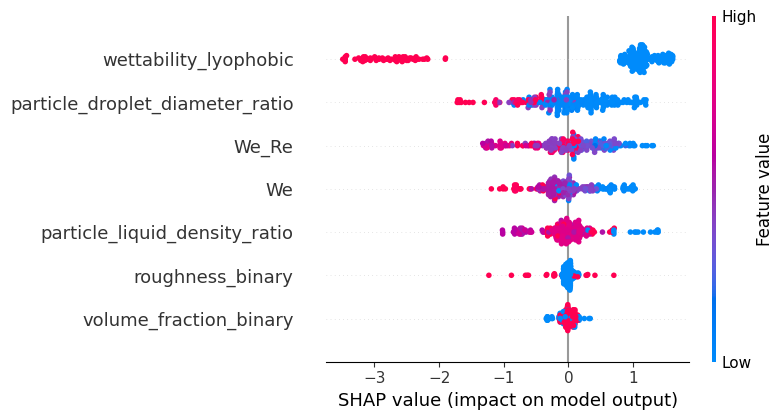

In [74]:
get_shap_interpretation(model, X_train)